In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean 
import cftime
import gsw
import cartopy
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

### load time mean global Temerpature (T) and Salinity (S) (function of latitude, longitude, and depth)

In [ ]:
woa18_data = xr.open_zarr('../data/woa18_full_decadal_ave_fields')

# ocean depth
etopo5_data = xr.open_dataset('http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NGDC/.ETOPO5/dods')
etopo5_data = etopo5_data.rename({'X': 'lon', 'Y': 'lat'})
etopo5_data['elev_ocean'] = etopo5_data.elev.where(etopo5_data.elev<0).load()
etopo5_data

In [3]:
# key fields we'll be working with
temp = woa18_data.temp
salt = woa18_data.salinity
depth = woa18_data.depth
elev = etopo5_data.elev
elev_ocean = etopo5_data.elev_ocean

## In this exercise, we are going to use global fields of T and S to:

- compute potential density
- estimate horizontal density gradients
- leverage the thermal wind relation to estimate geostrophic velocities associated with density gradients

We'll walk through a procedure step by step and generate some figures to get a sense of the distributions of temperature, salinity, and density throughout the ocean

### todo: Using the gibbs seawater package (gsw), compute at all latitudes, longitudes, and depths potential density referenced to the surface (sigma0). 

This will first require calculations of absolute salinity and conservative temperature. Remember sigma references some density - 1000 km/m^3.

In [4]:
help(gsw.pot_rho_t_exact)

Help on function pot_rho_t_exact in module gsw._wrapped_ufuncs:

pot_rho_t_exact(SA, t, p, p_ref)
    Calculates potential density of seawater.  Note. This function outputs
    potential density, not potential density anomaly; that is, 1000 kg/m^3
    is not subtracted.
    
    Parameters
    ----------
    SA : array-like
        Absolute Salinity, g/kg
    t : array-like
        In-situ temperature (ITS-90), degrees C
    p : array-like
        Sea pressure (absolute pressure minus 10.1325 dbar), dbar
    p_ref : array-like
        Reference pressure, dbar
    
    Returns
    -------
    pot_rho_t_exact : array-like, kg/m^3
        potential density (not potential density anomaly)
    
    
    References
    ----------
    IOC, SCOR and IAPSO, 2010: The international thermodynamic equation of
    seawater - 2010: Calculation and use of thermodynamic properties.
    Intergovernmental Oceanographic Commission, Manuals and Guides No. 56,
    UNESCO (English), 196 pp.  Available from 

In [5]:
pressure = (gsw.p_from_z(-depth, woa18_data.lat))
sigma0 = gsw.sigma0(salt, temp)
#Farther away from surface introduces more error
#if I want to reference to difference depths:
#change last term to set p ref
#will have both referenced to surface
rho_po= gsw.pot_rho_t_exact(salt, temp, pressure,0)

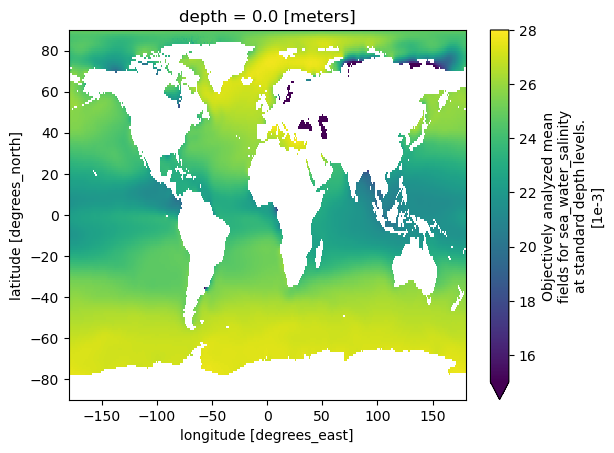

In [6]:
#rho_po.sel(depth=0, method='nearest').plot()
#referenced to surface
sigma0.sel(depth=0, method='nearest').plot(vmin=15,vmax=28)

### todo: Using cartopy produce a global map of T, S and potential density at the surface and at 1000m depth. 

In [7]:
#variables for the surfact and 1000m deep
temp0=temp.sel(depth=0)
temp1000=temp.sel(depth=1000)
salt0=salt.sel(depth=0)
salt1000=salt.sel(depth=1000)
rho_po0=rho_po.sel(depth=0)
rho_po1000=rho_po.sel(depth=1000)

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_8160\3594382531.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  f.colorbar(pp, cax=axins1, orientation="horizontal")


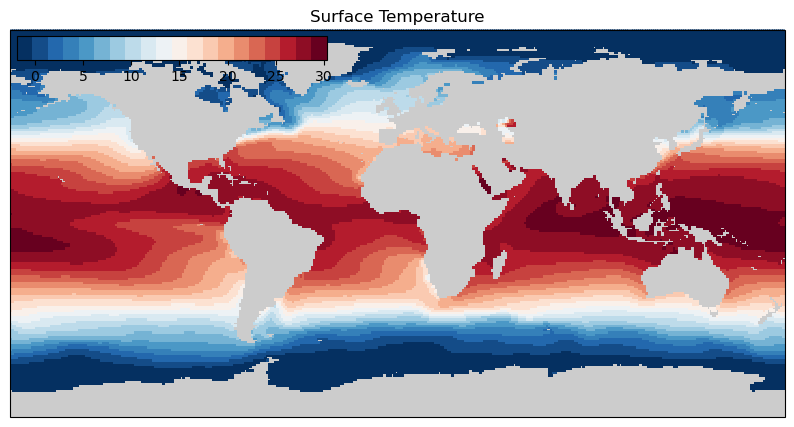

In [8]:
f, ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.PlateCarree()})
pp = ax.pcolor(temp0.lon, temp0.lat, temp0, #vmin=-1, vmax=1, \
          cmap=plt.get_cmap('RdBu_r',20),transform=ccrs.PlateCarree())
ax.set_facecolor('#cccccc')
ax.set_title('Surface Temperature')
axins1 = inset_axes(ax, width="40%",height="6%",loc="upper left")
ax.xaxis.set_ticks_position("top")
f.colorbar(pp, cax=axins1, orientation="horizontal")
ax.grid()

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_8160\1109474651.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  f.colorbar(pp, cax=axins1, orientation="horizontal")


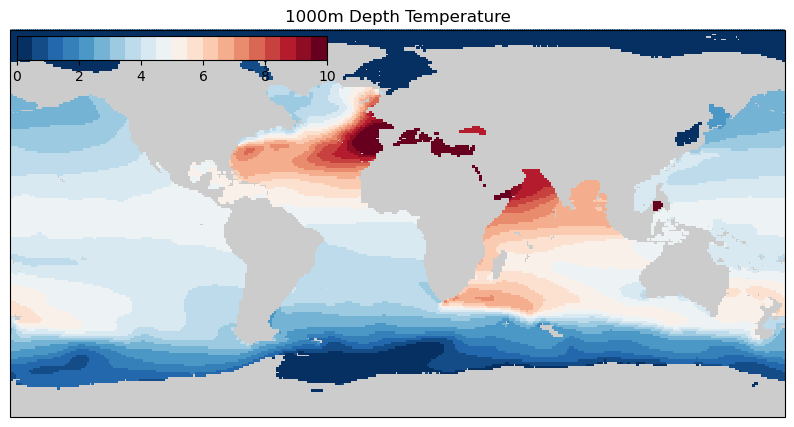

In [9]:
f, ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.PlateCarree()})
pp = ax.pcolor(temp1000.lon, temp1000.lat, temp1000, vmin=0, vmax=10, \
          cmap=plt.get_cmap('RdBu_r',20),transform=ccrs.PlateCarree())
ax.set_facecolor('#cccccc')
ax.set_title('1000m Depth Temperature')
axins1 = inset_axes(ax, width="40%",height="6%",loc="upper left")
ax.xaxis.set_ticks_position("top")
f.colorbar(pp, cax=axins1, orientation="horizontal")
ax.grid()

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_8160\874934642.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  f.colorbar(pp, cax=axins1, orientation="horizontal")


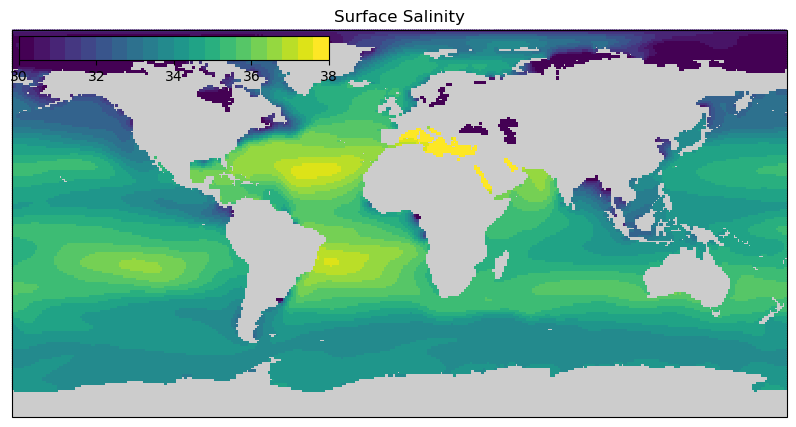

In [10]:
f, ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.PlateCarree()})
pp = ax.pcolor(salt0.lon, salt0.lat, salt0, vmin=30, vmax=38, \
          cmap=plt.get_cmap('viridis',20),transform=ccrs.PlateCarree())
ax.set_facecolor('#cccccc')
ax.set_title('Surface Salinity')
axins1 = inset_axes(ax, width="40%",height="6%",loc="upper left")
ax.xaxis.set_ticks_position("top")
f.colorbar(pp, cax=axins1, orientation="horizontal")
ax.grid()

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_8160\1684274424.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  f.colorbar(pp, cax=axins1, orientation="horizontal")


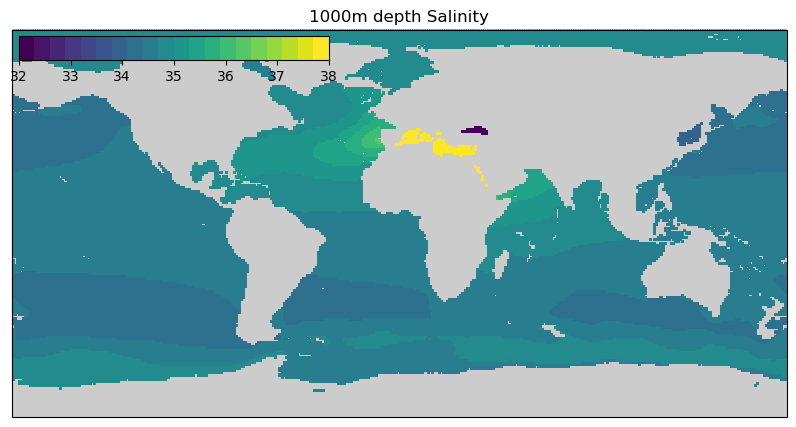

In [11]:
f, ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.PlateCarree()})
pp = ax.pcolor(salt1000.lon, salt1000.lat, salt1000, vmin=32, vmax=38, \
          cmap=plt.get_cmap('viridis',20),transform=ccrs.PlateCarree())
ax.set_facecolor('#cccccc')
ax.set_title('1000m depth Salinity')
axins1 = inset_axes(ax, width="40%",height="6%",loc="upper left")
ax.xaxis.set_ticks_position("top")
f.colorbar(pp, cax=axins1, orientation="horizontal")
ax.grid()

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_8160\2167281400.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  f.colorbar(pp, cax=axins1, orientation="horizontal")


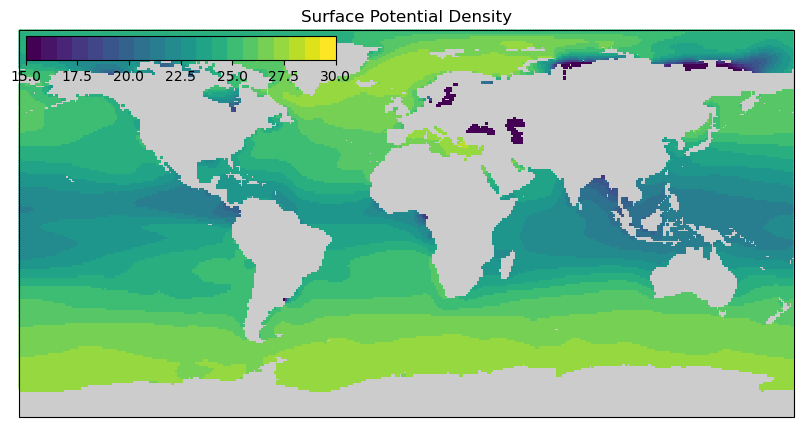

In [12]:
f, ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.PlateCarree()})
pp = ax.pcolor(rho_po0.lon, rho_po0.lat, rho_po0-1000, vmin=15, vmax=30, \
          cmap=plt.get_cmap('viridis',20),transform=ccrs.PlateCarree())
ax.set_facecolor('#cccccc')
ax.set_title('Surface Potential Density')
axins1 = inset_axes(ax, width="40%",height="6%",loc="upper left")
ax.xaxis.set_ticks_position("top")
f.colorbar(pp, cax=axins1, orientation="horizontal")
ax.grid()

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_8160\997589995.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  f.colorbar(pp, cax=axins1, orientation="horizontal")


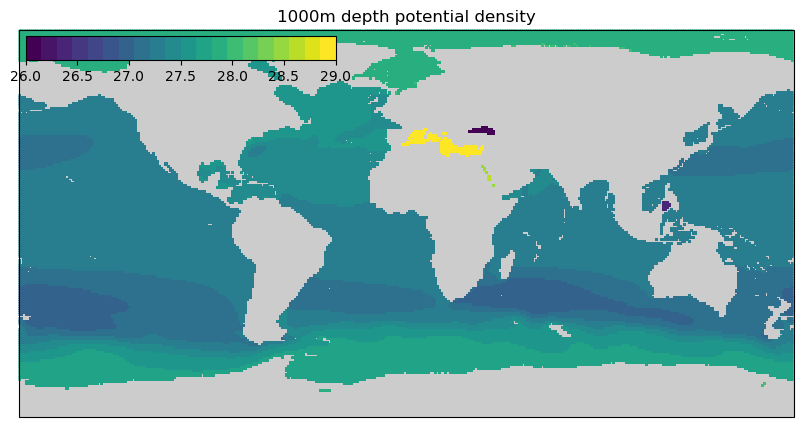

In [13]:
f, ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.PlateCarree()})
pp = ax.pcolor(rho_po1000.lon, rho_po1000.lat, rho_po1000-1000, vmin=26, vmax=29, \
          cmap=plt.get_cmap('viridis',20),transform=ccrs.PlateCarree())
ax.set_facecolor('#cccccc')
ax.set_title('1000m depth potential density')
axins1 = inset_axes(ax, width="40%",height="6%",loc="upper left")
ax.xaxis.set_ticks_position("top")
f.colorbar(pp, cax=axins1, orientation="horizontal")
ax.grid()

### todo: Write a few sentences about the patterns you observe (i.e. why is it warmer or saltier in certain regions?)

Each variable tends to homogenize at greater depths, with surface measurements being more highly varying. Regions of similar temperature and salinity, both at the surface and at depth, seem to represent distinct water masses. For example, a relatively high temp and high salinity water mass from the mediteranean is a watermass that is being sourced from the warm and saline mediteranean sea. Generally it appears that the larger/more continuous water masses can be seen at greater depths. At the surface, the climate (especially for temperature) may obscure where water masses may be. But overall, these plots reveal where in the oceans some of the distinct water masses exists and what some of their physical properties may be. 

### todo: Plot a cross section of potential density at 30W longitude (across all latitudes)

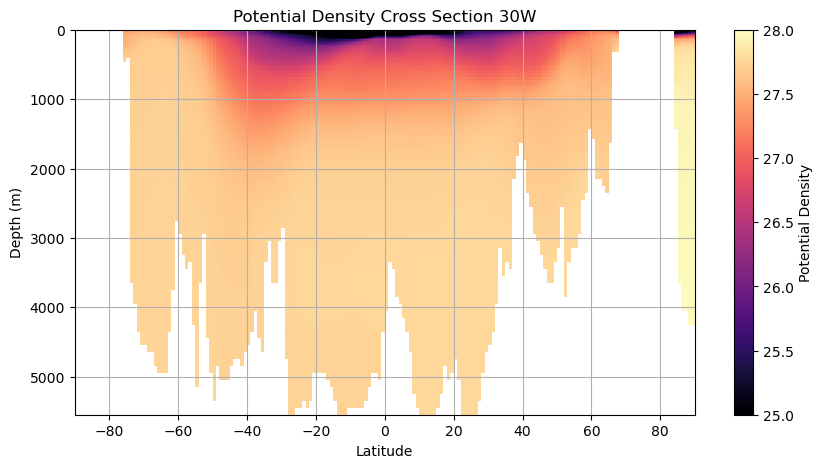

In [14]:
rho_po1=rho_po-1000
fig, ax = plt.subplots(figsize=(10,5))

# Plot and store the result in a variable (so we can use it for the colorbar)
plot = rho_po1.sel(lat=slice(-90,90)).sel(lon=-30, method="nearest").plot(
   ax=ax,
   cmap="magma",
    vmin=25,
    vmax=28,
   add_colorbar=False
)
# Customize axes and labels
ax.set_xlabel('Latitude')
ax.set_ylabel('Depth (m)')
ax.invert_yaxis()
ax.set_title('Potential Density Cross Section 30W')
ax.grid(True)

# Add colorbar with custom label
cb = plt.colorbar(plot, ax=ax)
cb.set_label('Potential Density') 

plt.show()

### todo: Along this cross-section, estimate and plot horizontal gradients of potential density ($\frac{\partial \sigma_0}{\partial y}$) 

(consider using the centered difference method and ignoring the latitudes for which a centered difference would be incomplete)

In [15]:
rho_po30w= rho_po1.sel(lat=slice(-90,90)).sel(lon=-30, method="nearest")
rho_po30w

<xarray.DataArray 'salinity' (depth: 102, lat: 180)>
dask.array<getitem, shape=(102, 180), dtype=float64, chunksize=(26, 45), chunktype=numpy.ndarray>
Coordinates:
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
    lon      float32 -29.5

In [17]:
rho=rho_po30w.values #just a little easier to write out
lat=rho_po30w.lat.values
depth=rho_po30w.depth.values
R = 6371000.0 #earth radius
# convert lats to radians for distance calculation
lats_rad = np.deg2rad(lat)
# allocate output gradient array
drho_dy = np.full(rho_po30w.shape, np.nan)
# number of lat points
Nlat = len(lat)

# loop over depth levels
for k in range(len(depth)):

    # extract density along this depth level
    rho_k = rho[k, :]
    
    # centered difference for 1 < i < N-1
    for i in range(1, Nlat - 1):
        
        # distance between (i-1) and (i+1)
        dphi = lats_rad[i+1] - lats_rad[i-1]   # radians
        dy = R * dphi                          # meters
        
        # centered derivative
        drho_dy[k, i] = (rho_k[i+1] - rho_k[i-1]) / dy

In [18]:
drho_dy

array([[           nan,            nan,            nan, ...,
        6.54797726e-07, 1.13065918e-06,            nan],
       [           nan,            nan,            nan, ...,
        8.23206870e-07, 1.21063945e-06,            nan],
       [           nan,            nan,            nan, ...,
        1.21024962e-06, 1.79773021e-06,            nan],
       ...,
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]])

### with horizontal gradients of potential density, we can estimate the vertical shear of zonal velocities as

$\Large\frac{\partial u}{\partial z} = \frac{g}{\rho_0 f} \frac{\partial \sigma_0}{\partial y}$

todo: evaluate the right hand side (compute and plot $\frac{\partial u}{\partial z}$)

In [19]:
#ρ = potential density (rho variable above)
#f = 2Ω sin(lat) (Coriolis parameter)
#g = 9.81 m/s²
#ρ₀ ≈ 1025 kg/m³ reference density
#∂ρ/∂y = meridional density gradient (above)

#setting up the variables
g=9.81
rho_ref=1025 #(reference density)
Omega = 7.2921e-5
f = 2*Omega*np.sin(np.deg2rad(lat))

du_dz = (g / (rho_ref * f)) * drho_dy

In [20]:
du_dz #velocity change with depth

array([[           nan,            nan,            nan, ...,
        4.30113662e-05, 7.42237828e-05,            nan],
       [           nan,            nan,            nan, ...,
        5.40735722e-05, 7.94742052e-05,            nan],
       [           nan,            nan,            nan, ...,
        7.94970530e-05, 1.18014641e-04,            nan],
       ...,
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]])

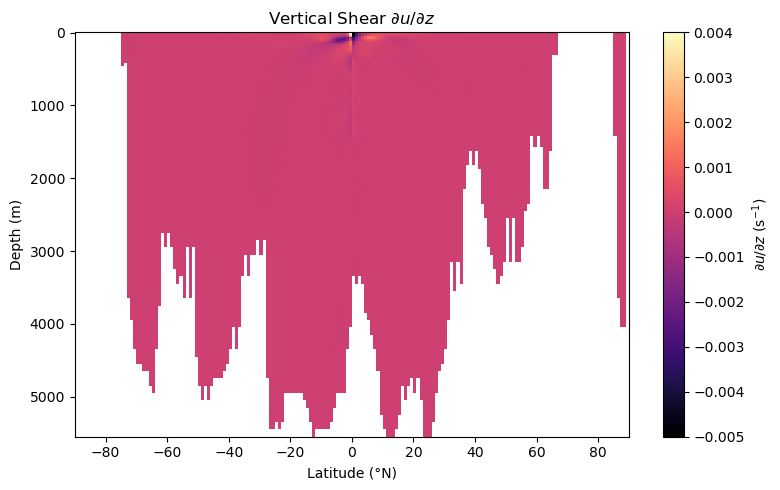

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

cs = ax.pcolormesh(lat, depth, du_dz, shading='nearest',
                   cmap='magma', vmin=-.005, vmax=0.004)

ax.set_xlabel("Latitude (°N)")
ax.set_ylabel("Depth (m)")
ax.invert_yaxis()

cbar = plt.colorbar(cs, ax=ax, label=r"$\partial u / \partial z$ (s$^{-1}$)")
plt.title("Vertical Shear $\\partial u / \\partial z$")
plt.tight_layout()
plt.show()

### todo: select 1000 m as your reference level (or level of no motion) and cumulatively integrate from z = -1000 m to the surface to obtain a profile of zonal velocity $u$

We'll first ignore everything below z = -1000 m and assume $u$ is zero at z = -1000 m. At each latitude, calculate a cumulative vertical  sum of the right hand side, at each level multiplied by $dz$ (the vertical distance separating values), upwards from z = -1000 m ... this approximates a $du$ that when cumulatively summed approximated the total vertical integral.

todo: plot $u$ over this cross-section and across this depth range (spanning all latitudes between z = 0 m and z = -1000 m)

In [37]:
# depths assumed positive downward
idx_1000 = np.argmin(np.abs(depth - 1000))

depth_sel = depth[:idx_1000+1]          # 0 → 1000 m
du_dz_sel = du_dz[:idx_1000+1, :]         # match depth dimension
dz = np.diff(depth_sel)  # array of length (Ndepth-1)
dz_2d = np.pad(dz, (1,0), constant_values=dz[0])[:, np.newaxis]   # shape (depth, 1)
# reverse arrays so we integrate upward (1000 → 0)
du_dz_rev = du_dz_sel[::-1, :]         # bottom → top
dz_rev = dz_2d[::-1]                   # match same order

# cumulative integral: u(1000 m) = 0
u_rev = np.cumsum(du_dz_rev * dz_rev, axis=0)

# flip back to normal (0 → 1000 m)
u_rel = u_rev[::-1, :]

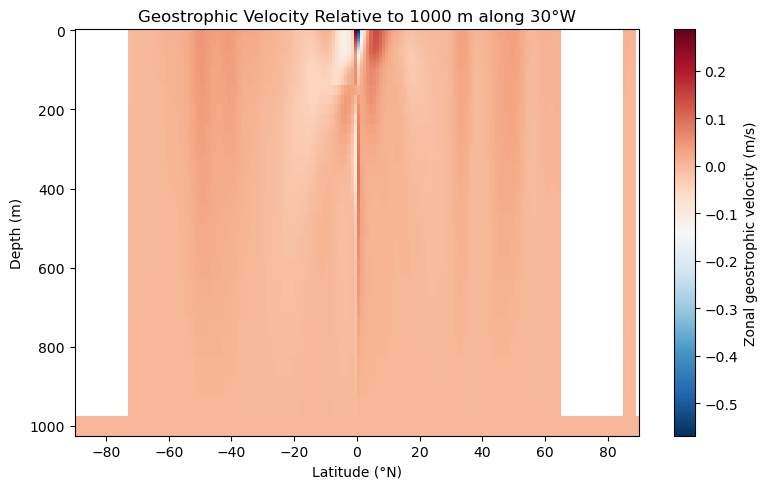

In [38]:
fig, ax = plt.subplots(figsize=(8,5))

cs = ax.pcolormesh(lat, depth_sel, u_rel, shading='nearest',
                   cmap='RdBu_r')

ax.invert_yaxis()
ax.set_xlabel("Latitude (°N)")
ax.set_ylabel("Depth (m)")
cbar = fig.colorbar(cs, ax=ax, label="Zonal geostrophic velocity (m/s)")
plt.title("Geostrophic Velocity Relative to 1000 m along 30°W")
plt.tight_layout()
plt.show()

### todo: redo the above calculation starting at z = -3000 m and then again at the seafloor

In [39]:
#3000
idx_3000 = np.argmin(np.abs(depth - 3000))

depth_sel2 = depth[:idx_3000+1]          # 0 → 1000 m
du_dz_sel2 = du_dz[:idx_3000+1, :]         # match depth dimension
dz2 = np.diff(depth_sel2)  # array of length (Ndepth-1)
dz_2d2 = np.pad(dz2, (1,0), constant_values=dz2[0])[:, np.newaxis]   # shape (depth, 1)
# reverse arrays so we integrate upward (1000 → 0)
du_dz_rev2 = du_dz_sel2[::-1, :]         # bottom → top
dz_rev2 = dz_2d2[::-1]                   # match same order

# cumulative integral: u(3000 m) = 0
u_rev2 = np.cumsum(du_dz_rev2 * dz_rev2, axis=0)

# flip back to normal (0 → 3000 m)
u_rel2 = u_rev2[::-1, :]

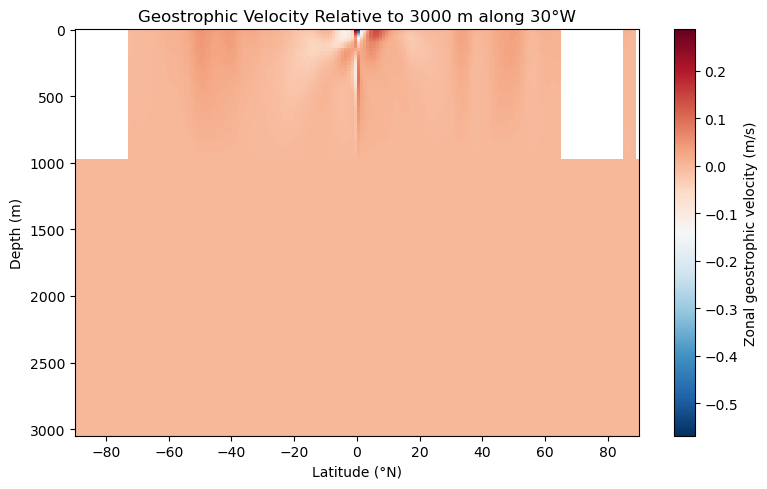

In [40]:
fig, ax = plt.subplots(figsize=(8,5))

cs = ax.pcolormesh(lat, depth_sel2, u_rel2, shading='nearest',
                   cmap='RdBu_r')

ax.invert_yaxis()
ax.set_xlabel("Latitude (°N)")
ax.set_ylabel("Depth (m)")
cbar = fig.colorbar(cs, ax=ax, label="Zonal geostrophic velocity (m/s)")
plt.title("Geostrophic Velocity Relative to 3000 m along 30°W")
plt.tight_layout()
plt.show()

In [48]:
#flor approximating as 5000m
idx_floor = np.argmin(np.abs(depth - 5000))

depth_sel3 = depth[:idx_floor+1]          # 0 → 1000 m
du_dz_sel3 = du_dz[:idx_floor+1, :]         # match depth dimension
dz3 = np.diff(depth_sel3)  # array of length (Ndepth-1)
dz_2d3 = np.pad(dz3, (1,0), constant_values=dz3[0])[:, np.newaxis]   # shape (depth, 1)
# reverse arrays so we integrate upward (1000 → 0)
du_dz_rev3 = du_dz_sel3[::-1, :]         # bottom → top
dz_rev3 = dz_2d3[::-1]                   # match same order

# cumulative integral: u(floor m) = 0
u_rev3 = np.cumsum(du_dz_rev3 * dz_rev3, axis=0)

# flip back to normal (0 → 1000 m)
u_rel3 = u_rev3[::-1, :]

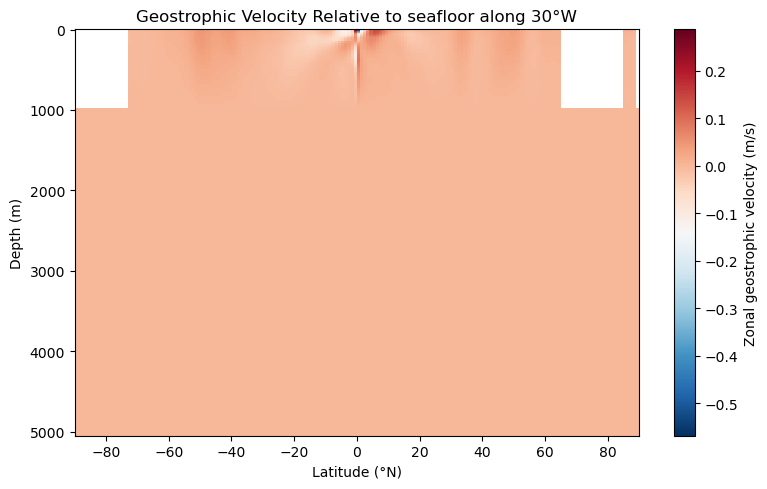

In [49]:
fig, ax = plt.subplots(figsize=(8,5))

cs = ax.pcolormesh(lat, depth_sel3, u_rel3, shading='nearest',
                   cmap='RdBu_r')

ax.invert_yaxis()
ax.set_xlabel("Latitude (°N)")
ax.set_ylabel("Depth (m)")
cbar = fig.colorbar(cs, ax=ax, label="Zonal geostrophic velocity (m/s)")
plt.title("Geostrophic Velocity Relative to seafloor along 30°W")
plt.tight_layout()
plt.show()

### todo: consider how estimates of $u$ over the upper 1000 m change as the refence level deepends. Write a few sentences about these differences, describe the features of $u$ that you observe, and connect them to know currents. 

All of these plots look very similar, which is probably an error on my part. Although I would anticipate that most of the change in shear is closer to the surface, so the deeper the reference point of zero is selected the more accurate the model.  